In [14]:
#Importing libraries
import itertools
import os
from os import mkdir
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.io.wavfile import write
import sounddevice as sd
import soundfile as sf
import pandas as pd


#Important parameters
spectral_density = [2] #tones per octave   
temporal_density = [16] #tones per second
ntokenreps = 16  #how many times the target repeats in a trial
tokendur = 0.4 #target duration
tempi = [0.4] #s, the inter-repeat interval of tokens  IOI

#Defining variables
tonedur = 0.05 
minf = 200
maxf = 12800 
noct = 6


fs = 44100 #generate sounds with this fs
# fs48 = 48828 #convert to this fs for TDT equipment
# maxf48k = fs48/2
# trialseed = 888

mintokenstart = 1 
maxtokenstart = 1.51 #first token starts between 1-1.5s into (random) tone cloud

tokenstartrange=np.arange(mintokenstart, maxtokenstart, 0.05)
tokenstartrange=np.round(tokenstartrange, 2)
    
# targetrms = (10**(-94/20))*(10**(stimdb/20)) #convertion of dB to amplitude. the number we would use
# targetrms_wav = 0.1 #0.4  

#Computing hann envelope (for creating a smooth on and off ramp to sounds)
hanndur = 0.005
thann = np.arange(1/fs, hanndur+1/fs, 1/fs)
ramp = np.cos(2*np.pi*0.5/hanndur*thann)
ttone = np.arange(1/fs, tonedur+1/fs, 1/fs)
env = np.ones(ttone.shape)
env[:len(ramp)] = np.flip(ramp)
env[-len(ramp):] = ramp
env=(env+1)/2
#plt.plot(ttone, env)

In [15]:
def timegrid_freqlist(td, sd, tokendur, tempi, ntokenreps, maxtokenstart, minf, maxf, noct):
    tokendur_ingrid =int(td*tokendur)
    tempi_ingrid = int(td*tempi[0])
    totaltime=maxtokenstart+(tempi[0]*ntokenreps)+1/td

    #Creating the freq_list and the timegrid
    trialct = 0
#         for s in range(len(spectral_density)):
#             specdens = spectral_density[s]
    freq_list = np.logspace(np.log10(minf),np.log10(maxf),sd*noct+1) #modified specdens by spectral_density
    timegrid=np.linspace(0,totaltime, num=int(totaltime/(1/(td))+2))
    return (tokendur_ingrid, tempi_ingrid, totaltime, freq_list, timegrid)


In [16]:
def f1_backgndmat(freq_list, timegrid, sd, td): 
    
    #Creating random background(latencymat, freqmat)
    latencymat = np.zeros((len(timegrid) - 1, len(freq_list) - 1))
    freqmat = np.zeros((len(timegrid) - 1, len(freq_list) - 1))

    for t in range(len(timegrid) - 2):     
        for f in range(len(freq_list) - 1):

            start_time = timegrid[t]
            end_time = timegrid[t + 1]
            ftimetone = np.random.uniform(start_time, end_time) - start_time

            fstart_time = freq_list[f]
            fend_time = freq_list[f + 1]
            ftone = np.random.uniform(fstart_time, fend_time)

            latencymat[t, f] = ftimetone
            freqmat[t, f] = ftone

    latencymat = latencymat.transpose()
    freqmat = freqmat.transpose()
    return (latencymat, freqmat)

In [17]:
def f2_tokenstarttime(Ntrials,tokenstartrange,nt):
    tokenstarttimes = []
    ultimo = None

    for _ in range(Ntrials+1):
        opciones = [x for x in tokenstartrange if x != ultimo]
        nuevo = random.choice(opciones)
        tokenstarttimes.append(nuevo)
        ultimo = nuevo
    
    tokenstarttime=tokenstarttimes[nt]
    return tokenstarttime

In [18]:
def f3_tokenmats(tokenstarttime, latencymat,freqmat, tokendur_ingrid, sd, td):
    #Creating token 
    #tokenendtime=tokenstarttime+tokendur 

    start_idx=int(tokenstarttime*td)

    end_idx=int(start_idx+tokendur_ingrid)
    latencytoken=latencymat[:,np.arange(start_idx,end_idx,1)]
    freqtoken=freqmat[:,np.arange(start_idx,end_idx,1)]

    #Creating the final soundmat of the tonecloud+token
    token_latencymat = latencymat
    token_freqmat = freqmat
    return (token_latencymat, token_freqmat, start_idx, freqtoken, latencytoken)


In [19]:
def f4_startids(tokenstarttime,token_latencymat, token_freqmat, latencymat, start_idx, tempi_ingrid, sd, td):
    latencyshape = latencymat.shape
    sid = np.arange(start_idx,latencyshape[1],tempi_ingrid)
    startids = [x for x in sid if x<(latencyshape[1]-2)]

#     print("latencytoken:\n",latencytoken)
#     print("\nfreqtoken:\n",freqtoken)
#     print("\nstartids:\n", startids)
    return (startids)

In [20]:
def f5_finalmats(startids,tokenstarttime,token_latencymat, token_freqmat, tokendur_ingrid, latencytoken, freqtoken, latencymat, freqmat, sd, td):
    baselatencymat=np.zeros(latencymat.shape)
    basefreqmat=np.zeros(freqmat.shape)

    #Replacing sections of tone cloud with token
    for s in startids:
        end_s = min(s + tokendur_ingrid, token_latencymat.shape[1])
        token_latencymat[:, s:end_s] = latencytoken[:, :end_s - s]
        token_freqmat[:, s:end_s] = freqtoken[:, :end_s - s]

        baselatencymat[:, s:end_s] = latencytoken[:, :end_s - s]
        basefreqmat[:, s:end_s] = freqtoken[:, :end_s - s]

        binarbasefreqmat = np.where(basefreqmat > 0, 1, basefreqmat)
        binarbaselatencymat = np.where(baselatencymat > 0, 1, baselatencymat)

#         print("Final token_latencymat:\n",token_latencymat)
#         print("\nFinal token_freqmat:\n",token_freqmat)
#         print("\nFinal token_freqmat:\n",binarbaselatencymat)
    return (token_latencymat, token_freqmat, binarbasefreqmat, binarbaselatencymat)



In [21]:
def f5b_finaljittermats(jitter, startids,tokenstarttime,token_latencymat, token_freqmat, tokendur_ingrid, sd, td, latencytoken, freqtoken, latencymat, freqmat):
    maxjitter = jitter # semitones, plus or minus
    jitterfreqtoken=np.zeros(freqtoken.shape)
    jitterperfreq=np.zeros(freqtoken.shape)

    baselatencymat=np.zeros(latencymat.shape)
    basefreqmat=np.zeros(freqmat.shape)

    # replace sections of tone cloud with token

    first_startid=startids[0]

    for s in startids:
        end_s = min(s + tokendur_ingrid, token_latencymat.shape[1])  # Limitar el índice final
        token_latencymat[:, s:end_s] = latencytoken[:, :end_s - s]

#                 token_latencymat[:, np.arange(s,s+tokendur_ingrid,1)] = latencytoken

#         maxjitter = 1 # semitones, plus or minus
#         jitterfreqtoken=np.zeros(freqtoken.shape)
#         jitterperfreq=np.zeros(freqtoken.shape)

        for i in range(freqtoken.shape[0]):
            for j in range(freqtoken.shape[1]):
                randjitterST = np.random.random(1)*maxjitter*2-maxjitter
                jitterfreq = freqtoken[i,j] * 2**(randjitterST/12)
                jitterfreqtoken[i][j]=jitterfreq
                jitterperfreq[i][j]=randjitterST
#                 print(jitterperfreq)
#                 print(jitterfreqtoken)

#                 jtoken_freqmat[:, np.arange(s,s+tokendur_ingrid,1)] = jitterfreqtoken
#                 jbaselatencymat[:, np.arange(s,s+tokendur_ingrid,1)] = latencytoken
#                 jbasefreqmat[:, np.arange(s,s+tokendur_ingrid,1)] = jitterfreqtoken
        token_freqmat[:, s:end_s] = jitterfreqtoken[:, :end_s - s]
        baselatencymat[:, s:end_s] = latencytoken[:, :end_s - s]
        basefreqmat[:, s:end_s] = jitterfreqtoken[:, :end_s - s]

        binarbasefreqmat = np.where(basefreqmat > 0, 1, basefreqmat)
        binarbaselatencymat = np.where(baselatencymat > 0, 1, baselatencymat)


#         print("Final token_latencymat:\n",token_latencymat)
#         print("\nFinal token_freqmat:\n",token_freqmat)

    return (token_latencymat, token_freqmat, binarbasefreqmat, binarbaselatencymat)


In [22]:
def f6_soundmat(timegrid, freq_list, token_latencymat, token_freqmat, env, totaltime, fs, sd, td, binarbaselatencymat, tonedur, ns, nt):
    tokensoundmat=np.zeros(int(totaltime*fs))
        
    for t in range(len(timegrid) - 2):     
        for f in range(len(freq_list) - 1):

            ftimetone = token_latencymat[f,t]
            ftone = token_freqmat[f,t]

            grid_start = timegrid[t]

            amp = np.sin(2*np.pi*ftone*ttone) #make the tone
            amp = amp*env #hanning env already calculated outside

            tonestartsamp = int((grid_start+ftimetone)*fs)+1
            toneendsamp = min(tonestartsamp+len(amp),len(tokensoundmat)) #we added the min adn len(tokensoundmat to add a limit here, part of the truncatin=ng provisional method)
            amp_segment = amp[:toneendsamp - tonestartsamp] #provisional truncating method to prevent an error if we use a temporal_density above 20
            tokensoundmat[tonestartsamp:toneendsamp]=tokensoundmat[tonestartsamp:toneendsamp]+amp_segment 
            
    return(tokensoundmat)

In [23]:
def f7_plotting(freq_list, timegrid, binarbaselatencymat, tonedur, sd, td, ns, nt, totaltime, token_latencymat, token_freqmat, expnum, setnum):
    
    graphs_path = f"C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/{expnum}-tesis/set{setnum}/graficas-exp1"  # Cambia el nombre si quieres otra carpeta

    os.makedirs(graphs_path, exist_ok=True)
    
    # plot grid (outside of loop)
    for t in timegrid:
        linetime=plt.axvline(x=t, color='gray', linestyle='--', linewidth=0.5)
    for f in freq_list:
        linefreq=plt.axhline(y=f, color='gray', linestyle='--', linewidth=0.5)

    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title(f'Tone cloud + Token\nspecdens {sd},tempdens {td}\n{expnum}-Set{setnum}-Trial {nt}\nTokendur {tokendur}-ioi{tempi[0]}')
    plt.xlim(0, totaltime)
    plt.ylim(minf, maxf+800)
    
    # add tones to grid
    for t in range(len(timegrid) - 2):     
        for f in range(len(freq_list) - 1):

            ftimetone = token_latencymat[f,t]
            ftone = token_freqmat[f,t]

            grid_start = timegrid[t]
    
            plt.plot([grid_start+ftimetone, grid_start+ftimetone + tonedur],[ftone, ftone], color='blue', linewidth=2)
            if binarbaselatencymat[f,t]==1:
                plt.plot([grid_start+ftimetone, grid_start+ftimetone + tonedur],[ftone, ftone], color='red', linewidth=2)
    
    filename = f"graphs_{expnum}_set{setnum}_trial{nt}_specd-{sd}_tempd-{td}_tokendur-{tokendur}_{totaltime}-sec.png"
    plt.savefig(os.path.join(graphs_path, filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return()

In [24]:
def f7_plottingj(jitter, freq_list, timegrid, binarbaselatencymat, tonedur, sd, td, ns, nt, totaltime, token_latencymat, token_freqmat, setnum):
    
    graphs_path = f"C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/jitter{jitter}/jitter{jitter}_set{setnum}/graficas-jitter{jitter}_set{setnum}"  # Cambia el nombre si quieres otra carpeta

    os.makedirs(graphs_path, exist_ok=True)
    
    # plot grid (outside of loop)
    for t in timegrid:
        linetime=plt.axvline(x=t, color='gray', linestyle='--', linewidth=0.5)
    for f in freq_list:
        linefreq=plt.axhline(y=f, color='gray', linestyle='--', linewidth=0.5)

    plt.xlabel('Time (s)')
    plt.ylabel('Frequency (Hz)')
    plt.title(f'Tone cloud + Token\nspecdens {sd},tempdens {td}\njitterlevel{jitter}-Set{setnum}-Trial {nt}\nTokendur {tokendur}-ioi{tempi[0]}')
    plt.xlim(0, totaltime)
    plt.ylim(minf, maxf+800)
    
    # add tones to grid
    for t in range(len(timegrid) - 2):     
        for f in range(len(freq_list) - 1):

            ftimetone = token_latencymat[f,t]
            ftone = token_freqmat[f,t]

            grid_start = timegrid[t]
    
            plt.plot([grid_start+ftimetone, grid_start+ftimetone + tonedur],[ftone, ftone], color='blue', linewidth=2)
            if binarbaselatencymat[f,t]==1:
                plt.plot([grid_start+ftimetone, grid_start+ftimetone + tonedur],[ftone, ftone], color='red', linewidth=2)
    
    filename = f"graphs_j{jitter}_set{setnum}_trial{nt}_specd-{sd}_tempd-{td}_tokendur-{tokendur}_{totaltime}-sec.png"
    plt.savefig(os.path.join(graphs_path, filename), dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()
    return()

In [25]:
def f8_savingfile(tokensoundmat, trial, setnum, expnum, setspath, sd, td, tokendur, totaltime):
    #Creating and saving wav file

    filename= f"{expnum}_set{setnum}_trial{trial}_specd-{sd}_tempd-{td}_tokendur-{tokendur}_ioi-{tempi[0]}_{totaltime}-sec.wav"
    path_filename = os.path.join(setspath, filename)

    tokensoundmat = tokensoundmat/max(abs(tokensoundmat))
    sf.write(path_filename, tokensoundmat, fs)

    return filename

In [26]:
def f8_savingfilej(jitter, tokensoundmat, trial, setnum, setspath, sd, td, tokendur, totaltime):
    #Creating and saving wav file

    filename= f"j{jitter}_set{setnum}_trial{trial}_specd-{sd}_tempd-{td}_tokendur-{tokendur}_ioi-{tempi[0]}_{totaltime}-sec.wav"
    path_filename = os.path.join(setspath, filename)
    
    tokensoundmat = tokensoundmat/max(abs(tokensoundmat))
    sf.write(path_filename, tokensoundmat, fs)

    return filename

In [27]:
def f9_savinginfo(filename, nt, trialseed, tokenstarttime, token_freqmat, setspath, expnum, setnum, alltrials_csv_exp1, alltrials_info_exp1, addmatrix):

    alltrials_info_exp1[filename] = {
        "id": nt,
        "trialseed": trialseed,
        "tokenstarttime": tokenstarttime,
        "token_freqmat": token_freqmat
    }

    # Prepara datos para exportar (sin la matriz, o como string si la quieres)
    row = {
        "id": nt,
        "filename": filename,
        "trialseed": trialseed,
        "tokenstarttime": tokenstarttime
    }

    if addmatrix:
        row["token_freqmat"] = token_freqmat.tolist()  # convierte a lista anidada

    alltrials_csv_exp1.append(row)
    
    #save dictionary
    
    path= f"C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/exp1-tesis/set{setnum}/{expnum}_set{setnum}_total{Ntrials}_sd{sd}_td{td}/"
    
    import pickle as pickle
    pklfilename = f"all-trials-info_{expnum}_set{setnum}.pkl"
    pklpath = os.path.join(path, pklfilename)
    os.makedirs(os.path.dirname(pklpath), exist_ok=True)
    
    with open(pklpath, "wb") as f:
        pickle.dump(alltrials_info_exp1, f)
        
    #save csv
    df = pd.DataFrame(alltrials_csv_exp1)
    csvfilename= f"all-trials-info_{expnum}_set{setnum}.csv"
    csvpath = path + csvfilename
    df.to_csv(csvpath, index=False) 
    

    return alltrials_info_exp1



In [28]:
def f9_savinginfoj(jitter, filename, nt, trialseed, tokenstarttime, token_freqmat, setspath, setnum, alltrials_csv, alltrials_info, addmatrix):

    alltrials_info[filename] = {
        "id": nt,
        "jitter_level": jitter,
        "trialseed": trialseed,
        "tokenstarttime": tokenstarttime,
        "token_freqmat": token_freqmat
    }

    # Prepara datos para exportar (sin la matriz, o como string si la quieres)
    row = {
        "id": nt,
        "jitter_level": jitter,
        "filename": filename,
        "trialseed": trialseed,
        "tokenstarttime": tokenstarttime
    }

    if addmatrix:
        row["token_freqmat"] = token_freqmat.tolist()  # convierte a lista anidada

    alltrials_csv.append(row)

    #save dictionary
    
    path= f"C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/jitter{jitter}/jitter{jitter}_set{setnum}/jitter{jitter}_set{setnum}_specd{sd}_tempd{td}_total{Ntrials}/"
    
    import pickle as pickle
    pklfilename = f"all-trials-info_jitter{jitter}_set{setnum}.pkl"
    pklpath = os.path.join(path, pklfilename)
    os.makedirs(os.path.dirname(pklpath), exist_ok=True)
    
    with open(pklpath, "wb") as f:
        pickle.dump(alltrials_info, f)
        
    #save csv
    df = pd.DataFrame(alltrials_csv)
    csvfilename= f"all-trials-info_jitter{jitter}_set{setnum}.csv"
    csvpath = path + csvfilename
    df.to_csv(csvpath, index=False) 

    return alltrials_info


C:\Users\Laptop Elitebook\AppData\Local\Temp\ipykernel_7300\2941206842.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  jitterfreqtoken[i][j]=jitterfreq
C:\Users\Laptop Elitebook\AppData\Local\Temp\ipykernel_7300\2941206842.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  jitterperfreq[i][j]=randjitterST


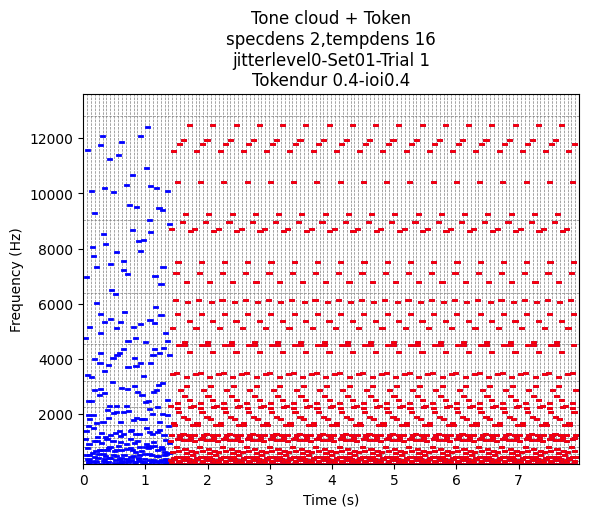

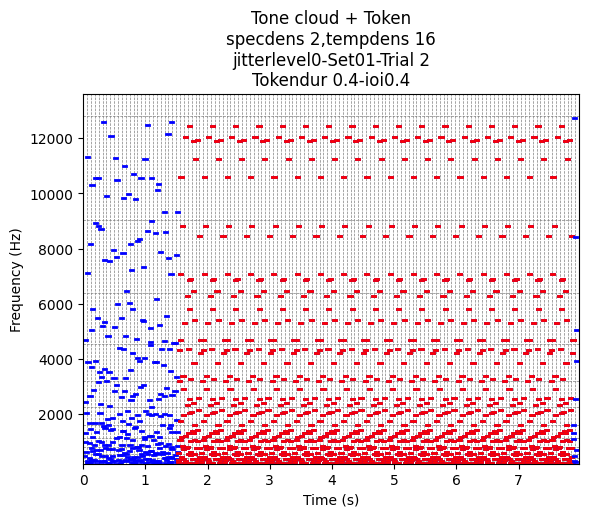

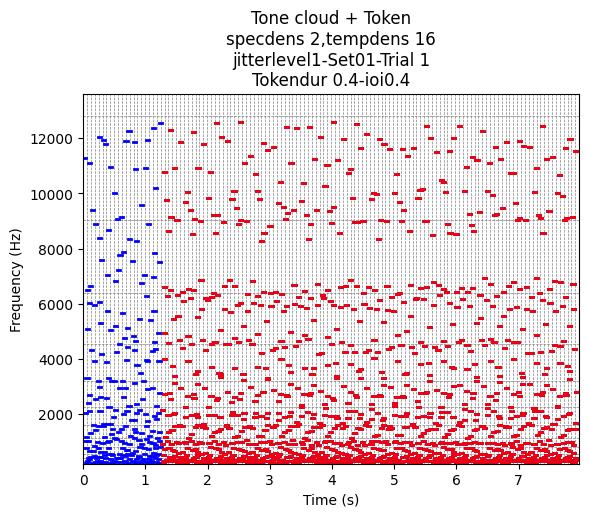

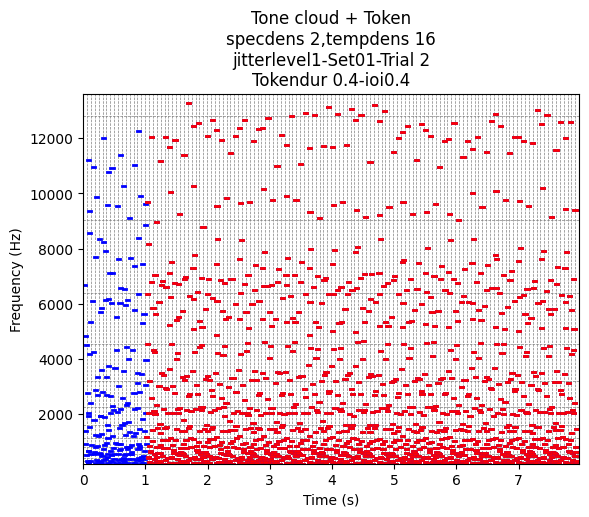

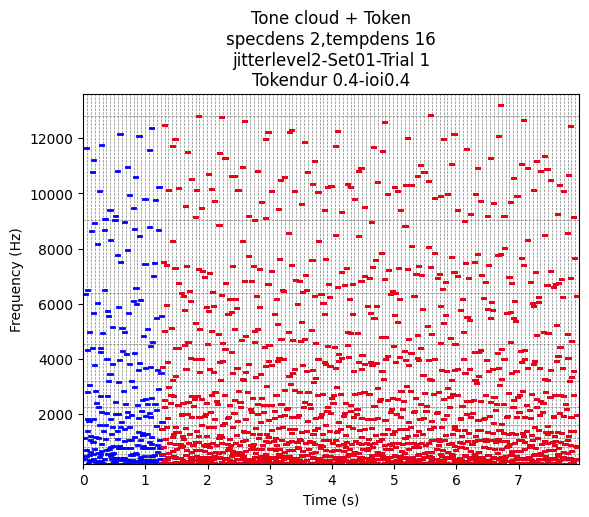

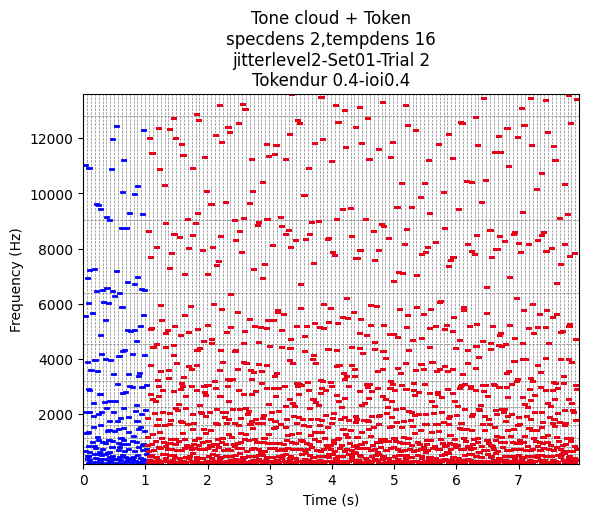

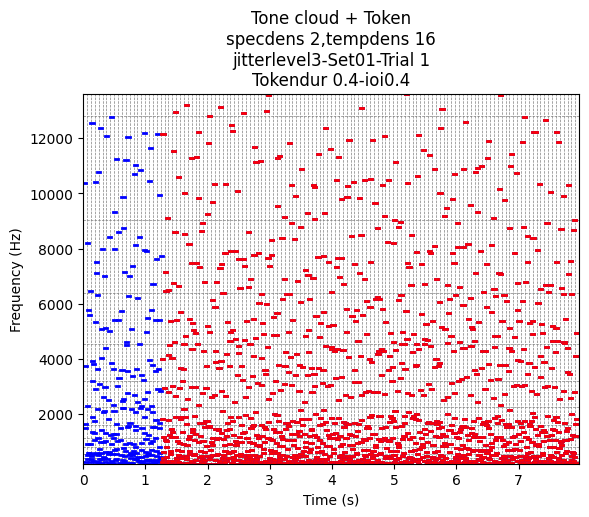

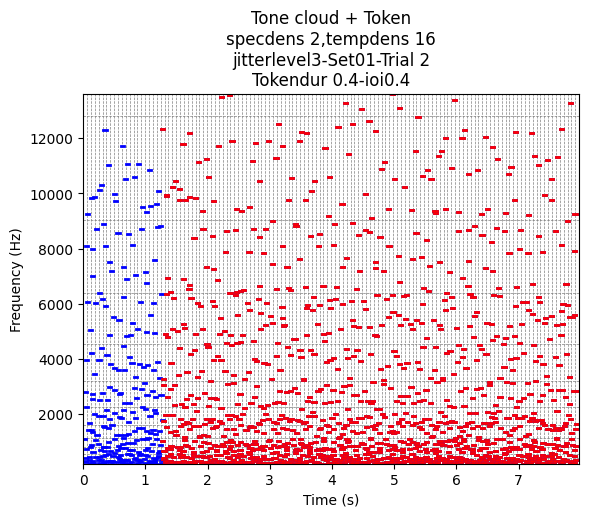

In [31]:
Ntrials=2
Nsets=1

jitter_levels=[0,1,2,3]

def tesis_stimulusset(Ntrials,Nsets, sd, td, jitter_levels):
    
    #generating and defining the basic stuff
    tokendur_ingrid, tempi_ingrid, totaltime, freq_list, timegrid= timegrid_freqlist(td, sd, tokendur, tempi, ntokenreps, maxtokenstart, minf, maxf, noct)
    
    #Looping trough the desired number of subjects and number of trials.
    for ns in range(1, Nsets + 1):
        for jitter in jitter_levels:
            setnum= str(ns).zfill(2)
            setsfolder= f"jitter{jitter}_set{setnum}_specd{sd}_tempd{td}_total{Ntrials}/"
            setspath = os.path.join(f"C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/jitter{jitter}/jitter{jitter}_set{setnum}/", setsfolder)
            os.makedirs(setspath, exist_ok=True)


            alltrials_info = {}
            alltrials_csv= []

            for nt in range(1, Ntrials + 1):

                trialseed=np.random.randint(0, 1e6)
                np.random.seed(trialseed)

                #call function to create background token cloud given the freq_list and timegrid
                latencymat, freqmat= f1_backgndmat(freq_list, timegrid, sd, td)

                tokenstarttime= f2_tokenstarttime(Ntrials,tokenstartrange,nt)

                #call function to create tokenstarttime,token_latencymat, token_freqmat given a latencymat,freqmat and tokendur_ingrid
                token_latencymat, token_freqmat, start_idx, freqtoken, latencytoken= f3_tokenmats(tokenstarttime, latencymat,freqmat, tokendur_ingrid, sd, td)

                #call function to create startids given a tokenstarttime,token_latencymat, token_freqmat, start_idx, tempi_ingrid
                startids= f4_startids(tokenstarttime,token_latencymat, token_freqmat, latencymat, start_idx, tempi_ingrid, sd, td)

                #call function to insert the tokens into the final mats, given the startids,tokenstarttime,token_latencymat, token_freqmat and tokendur_ingrid 
                token_latencymat, token_freqmat, binarbasefreqmat, binarbaselatencymat = f5b_finaljittermats(jitter, startids,tokenstarttime,token_latencymat, token_freqmat, tokendur_ingrid, sd, td, latencytoken, freqtoken, latencymat, freqmat)

                #call function to create a soundmat, given the timegrid, freq_list, token_latencymat, token_freqmat and env
                tokensoundmat = f6_soundmat(timegrid, freq_list, token_latencymat, token_freqmat, env, totaltime, fs, sd, td, binarbaselatencymat, tonedur, ns, nt)

                #call function to plot, given the freq_list, timegrid, tokensoundmat, binarbaselatencymat, ftone, ftimetone, grid_start, tonedur
                f7_plottingj(jitter, freq_list, timegrid, binarbaselatencymat, tonedur, sd, td, ns, nt, totaltime, token_latencymat, token_freqmat, setnum)

                #call function to create and save wav file given a tokensoundmat, trial, filename, subjpath

                trial= str(nt).zfill(2)
                setnum= str(ns).zfill(2)

                filename= f8_savingfilej(jitter, tokensoundmat, trial, setnum, setspath, sd, td, tokendur, totaltime)

                f9_savinginfoj(jitter, filename, nt, trialseed, tokenstarttime, token_freqmat, setspath, setnum, alltrials_csv, alltrials_info, addmatrix=False)

        return alltrials_info


for sd, td in itertools.product(spectral_density, temporal_density):
    alltrials_info=tesis_stimulusset(Ntrials,Nsets, sd, td, jitter_levels)


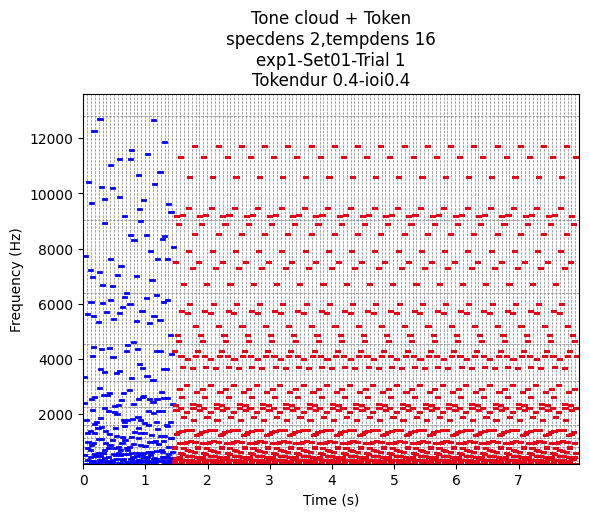

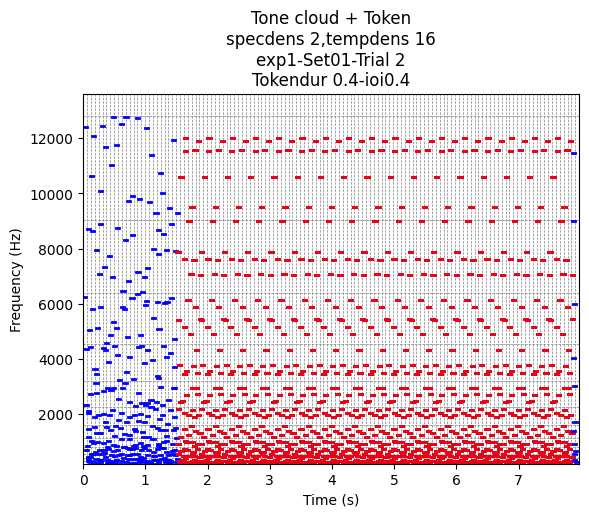

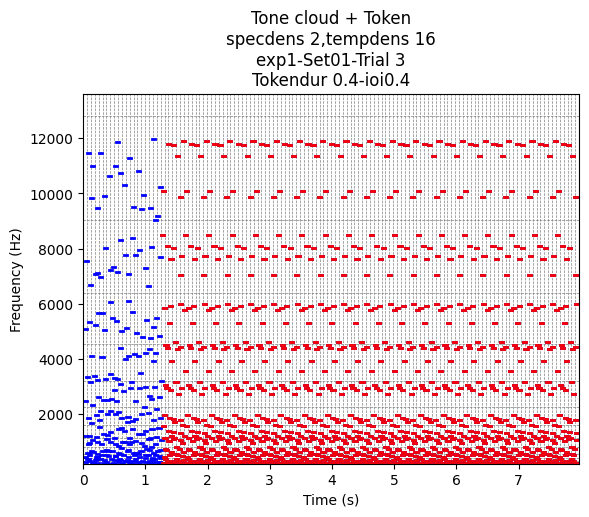

In [29]:
Ntrials=3
Nsets=1

def exp1_stimulusset(Ntrials,Nsets, sd, td):
    
    #generating and defining the basic stuff
    
    tokendur_ingrid, tempi_ingrid, totaltime, freq_list, timegrid= timegrid_freqlist(td, sd, tokendur, tempi, ntokenreps, maxtokenstart, minf, maxf, noct)
    
    #Looping trough the desired number of subjects and number of trials.
    
    for ns in range(1, Nsets + 1):
        np.random.seed(ns)
        expnum="exp1"
        setnum= str(ns).zfill(2)
        setsfolder= f"{expnum}_set{setnum}_total{Ntrials}_sd{sd}_td{td}"
        setspath = os.path.join(f"C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/{expnum}-tesis/set{setnum}/", setsfolder)
        os.makedirs(setspath, exist_ok=True)
        
        alltrials_info_exp1 = {}
        alltrials_csv_exp1 = []

        for nt in range(1, Ntrials + 1):
            
            trialseed=np.random.randint(0, 1e6) 
            np.random.seed(trialseed)
            
            #call function to create background token cloud given the freq_list and timegrid
            latencymat, freqmat= f1_backgndmat(freq_list, timegrid, sd, td)
            
            tokenstarttime= f2_tokenstarttime(Ntrials,tokenstartrange,nt)

            #call function to create tokenstarttime,token_latencymat, token_freqmat given a latencymat,freqmat and tokendur_ingrid
            token_latencymat, token_freqmat, start_idx, freqtoken, latencytoken= f3_tokenmats(tokenstarttime, latencymat,freqmat, tokendur_ingrid, sd, td)

            #call function to create startids given a tokenstarttime,token_latencymat, token_freqmat, start_idx, tempi_ingrid
            startids= f4_startids(tokenstarttime,token_latencymat, token_freqmat, latencymat, start_idx, tempi_ingrid, sd, td)

            #call function to insert the tokens into the final mats, given the startids,tokenstarttime,token_latencymat, token_freqmat and tokendur_ingrid 
            token_latencymat, token_freqmat, binarbasefreqmat, binarbaselatencymat = f5_finalmats(startids,tokenstarttime,token_latencymat, token_freqmat, tokendur_ingrid, latencytoken, freqtoken, latencymat, freqmat, sd, td)

            #call function to create a soundmat, given the timegrid, freq_list, token_latencymat, token_freqmat and env
            tokensoundmat = f6_soundmat(timegrid, freq_list, token_latencymat, token_freqmat, env, totaltime, fs, sd, td, binarbaselatencymat, tonedur, ns, nt)
            
            #call function to plot, given the freq_list, timegrid, tokensoundmat, binarbaselatencymat, ftone, ftimetone, grid_start, tonedur
            f7_plotting(freq_list, timegrid, binarbaselatencymat, tonedur, sd, td, ns, nt, totaltime, token_latencymat, token_freqmat, expnum, setnum)

            #call function to create and save wav file given a tokensoundmat, trial, filename, subjpath

            trial= str(nt).zfill(2)
            setnum= str(ns).zfill(2)

            filename= f8_savingfile(tokensoundmat, nt, setnum, expnum, setspath, sd, td, tokendur, totaltime)
            
            f9_savinginfo(filename, nt, trialseed, tokenstarttime, token_freqmat, setspath, expnum, setnum, alltrials_csv_exp1, alltrials_info_exp1, addmatrix=True)
            
    return alltrials_info_exp1
                
for sd, td in itertools.product(spectral_density, temporal_density):
    alltrials_info_exp1=exp1_stimulusset(Ntrials, Nsets, sd, td)

In [ ]:
#T Task  #ioi 0.6
#guarda los token start times en un csv

#out of the function

Ntrials=2
Nsubjects=1

#Importing libraries
import itertools
import os
from os import mkdir
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.io.wavfile import write
import sounddevice as sd
import soundfile as sf
import csv


#Important parameters
spectral_density = 2 #tones per octave   
temporal_density = 20 #tones per second
ntokenreps = 16  #how many times the target repeats in a trial
tempi = [0.4] #s, #IOI, the inter-repeat interval of tokens
tokendur = 0.4

# if tempi== tempi[0]
#     ntokenreps = 25
#     elif tempi == tempi[0]
#         ntokenreps = 15

#tokendur = tempi*snr #target duration

#Defining variables
tonedur = 0.05 
minf = 200
maxf = 12800
noct = 4
nrandom= 3 #seconds of random at the end of each trial


csv_path = F"C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios/expC3/TPtask-Easy_tempi{tempi[0]}_{Ntrials}audios.csv"
with open(csv_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    tempinums=[] #para agregar al excel título a cada valor de ioi que corresponda al numero de token que representa
    for i in range(2,ntokenreps+2):
        str(i+1)
        tempinums.append(i)
    writer.writerow(["id", "filename", "seed","tokenstarttime"]+tempinums)
    
    audio_index = 1


    fs = 44100 #generate sounds with this fs
    fs48 = 48828 #convert to this fs for TDT equipment
    maxf48k = fs48/2
    #trialseed = 888


    mintokenstart = 1 
    maxtokenstart = 1.51 #first token starts between 1-1.5s into (random) tone cloud

    tokenstartrange=np.arange(mintokenstart, maxtokenstart, 0.05)
    tokenstartrange=np.round(tokenstartrange, 2)
    
    tokenstarttimes = []
    ultimo = None

    for _ in range(Ntrials+1):
        seed = np.random.randint(0, 1e6)  
        np.random.seed(seed) 
        
        opciones = [x for x in tokenstartrange if x != ultimo]
        nuevo = random.choice(opciones)
        tokenstarttimes.append(nuevo)
        ultimo = nuevo


    #np.random.seed(trialseed)  #command to set the seed
    ntrialspercond = 60
    stimdb = 85

    targetrms = (10**(-94/20))*(10**(stimdb/20)) #convertion of dB to amplitude. the number we would use
    targetrms_wav = 0.1 #0.4  

    #Computing hann envelope (for creating a smooth on and off ramp to sounds)
    hanndur = 0.005
    thann = np.arange(1/fs, hanndur+1/fs, 1/fs)
    ramp = np.cos(2*np.pi*0.5/hanndur*thann)
    ttone = np.arange(1/fs, tonedur+1/fs, 1/fs)
    env = np.ones(ttone.shape)
    env[:len(ramp)] = np.flip(ramp)
    env[-len(ramp):] = ramp
    env=(env+1)/2
    #plt.plot(ttone, env)


    tokendur_ingrid =int(temporal_density*tokendur)
    tempi_ingrid = int(temporal_density*tempi[0])
    totaltime=(maxtokenstart+(tempi[0]*ntokenreps)+1/temporal_density)


    #Creating the freq_list and the timegrid
    trialct = 0
    #         for s in range(len(spectral_density)):
    #             specdens = spectral_density[s]
    freq_list = np.logspace(np.log10(minf),np.log10(maxf),int(spectral_density*noct+1)) #modified specdens by spectral_density
    timegrid=np.linspace(0,totaltime, num=int(totaltime/(1/(temporal_density))+2))


    #Looping trough the desired number of subjects and number of trials.
    for ns in range(1, Nsubjects + 1):

        subjID= str(ns).zfill(2)
        subjfolder= f"TPtask-Easy_ioi_{tempi[0]}_specd{spectral_density}_tempd{temporal_density}_subject{subjID}_total{Ntrials}"
        subjpath = os.path.join("C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios/expC3", subjfolder)
        os.makedirs(subjpath, exist_ok=True)
        
        for nt in range(1, Ntrials + 1):
            
            tokenstarttime=tokenstarttimes[nt]
            
            seed = np.random.randint(0, 1e6)  
            # seed= 687535
            np.random.seed(seed) 

            #Creating random background(latencymat, freqmat)
            latencymat = np.zeros((len(timegrid) - 1, len(freq_list) - 1))
            freqmat = np.zeros((len(timegrid) - 1, len(freq_list) - 1))

            for t in range(len(timegrid) - 2):     
                for f in range(len(freq_list) - 1):

                    start_time = timegrid[t]
                    end_time = timegrid[t + 1]
                    ftimetone = np.random.uniform(start_time, end_time) - start_time

                    fstart_time = freq_list[f]
                    fend_time = freq_list[f + 1]
                    ftone = np.random.uniform(fstart_time, fend_time)

                    latencymat[t, f] = ftimetone
                    freqmat[t, f] = ftone

            latencymat = latencymat.transpose()
            freqmat = freqmat.transpose()
            

    #             print("Latencymat:\n",latencymat)
    #             print("\nFreqmat:\n",freqmat)


            #Creating token and startids
            #range from where I can choose to start my token
        
                
            #tokenstarttime = np.random.uniform(1, 1.5)
            tokenendtime=tokenstarttime+tokendur 

            start_idx=int(tokenstarttime*temporal_density)

            end_idx=int(start_idx+tokendur_ingrid)

            latencytoken=latencymat[:,np.arange(start_idx,end_idx,1)]
            freqtoken=freqmat[:,np.arange(start_idx,end_idx,1)]

            latencyshape = latencymat.shape
            sid = np.arange(start_idx,latencyshape[1],tempi_ingrid)
            startids = [x for x in sid if x<(latencyshape[1]-2)]
            startids = startids[:ntokenreps] #porque me estaba dando una repeticion extra

    #             print("latencytoken:\n",latencytoken)
    #             print("\nfreqtoken:\n",freqtoken)
    #             print("\nstartids:\n", startids)

            #Creating the final soundmat of the tonecloud+token
            token_latencymat = latencymat
            token_freqmat = freqmat

            baselatencymat=np.zeros(latencymat.shape)
            basefreqmat=np.zeros(freqmat.shape)

            #Replacing sections of tone cloud with token
            for s in startids:
                end_s = min(s + tokendur_ingrid, token_latencymat.shape[1])
                token_latencymat[:, s:end_s] = latencytoken[:, :end_s - s]
                token_freqmat[:, s:end_s] = freqtoken[:, :end_s - s]

                baselatencymat[:, s:end_s] = latencytoken[:, :end_s - s]
                basefreqmat[:, s:end_s] = freqtoken[:, :end_s - s]

                binarbasefreqmat = np.where(basefreqmat > 0, 1, basefreqmat)
                binarbaselatencymat = np.where(baselatencymat > 0, 1, baselatencymat)

    #             print("Final token_latencymat:\n",token_latencymat)
    #             print("\nFinal token_freqmat:\n",token_freqmat)


            tokensoundmat=np.zeros(int(totaltime*fs))

#             tokensoundmat = np.append(tokensoundmat, np.zeros(int(nrandom * fs))) Esta parte era la que hacía que al final no sonara

            for t in range(len(timegrid) - 2):     
                for f in range(len(freq_list) - 1):

                    ftimetone = token_latencymat[f,t]
                    ftone = token_freqmat[f,t]

                    grid_start = timegrid[t]

                    amp = np.sin(2*np.pi*ftone*ttone) #make the tone
                    amp = amp*env #hanning env already calculated outside

                    tonestartsamp = int((grid_start+ftimetone)*fs)+1
                    toneendsamp = min(tonestartsamp+len(amp),len(tokensoundmat)) #we added the min adn len(tokensoundmat to add a limit here, part of the truncatin=ng provisional method)
                    amp_segment = amp[:toneendsamp - tonestartsamp] #provisional truncating method to prevent an error if we use a temporal_density above 20


                    #print(grid_start,tonestartsamp)


                    tokensoundmat[tonestartsamp:toneendsamp]=tokensoundmat[tonestartsamp:toneendsamp]+amp_segment #
                    plt.plot([grid_start+ftimetone, grid_start+ftimetone + tonedur],[ftone, ftone], color='blue', linewidth=2)
                    if binarbaselatencymat[f,t]==1:
                        plt.plot([grid_start+ftimetone, grid_start+ftimetone + tonedur],[ftone, ftone], color='red', linewidth=2)

            for t in timegrid:
                linetime=plt.axvline(x=t, color='gray', linestyle='--', linewidth=0.5)
            for f in freq_list:
                linefreq=plt.axhline(y=f, color='gray', linestyle='--', linewidth=0.5)

            plt.xlabel('Time (s)')
            plt.ylabel('Frequency (Hz)')
            plt.title(f'Ejemplo de nube de tono\n{ntokenreps} tokens de {tokendur}s de duración\nioi{tempi[0]}')
            plt.xlim(0, totaltime)
            plt.ylim(minf, maxf+800)
            plt.show()


            #Creating and saving wav file

            trial= str(nt).zfill(2)
            filename= f"TPtask-Easy_trial{trial}_ioi-{tempi[0]}_specd-{spectral_density}_tempd-{temporal_density}_tokendur-{tokendur}_seed-{seed}_{totaltime}-sec.wav"
            path_filename = os.path.join(subjpath, filename)

            current_time=tokenstarttime

            iois= []  #genero una lista con el ioi repetidos el numero de veces que se repite el token al cual representa
            for i in range(ntokenreps):
                iois.append(tempi[0])

            ioitimes = []

            for ioi in iois:
                current_time += ioi #voy sumando mis valores de ioi para generar una suma acumulada y por tanto indices que avanzan en el tiempo, iniciando por start_idx
                if current_time >= totaltime or len(ioitimes) > ntokenreps:  # Asegúrate de no exceder el límite
                    break  # Detener el ciclo si se supera el límite
                ioitimes.append(current_time)

            tokensoundmat = tokensoundmat/max(abs(tokensoundmat))
            sf.write(path_filename, tokensoundmat, fs)


            writer.writerow([audio_index, filename, seed, tokenstarttime]+ioitimes)
            audio_index += 1


            print(f"Saved: {path_filename}") 

In [39]:
#intento ejemplo de aleatorizacon de audios por bloques
import os
import pandas as pd
import numpy as np

def mezclar_bloques_sin_repetir(ruta_base, jitter_levels, Nsets, Ntrials, spectral_density, temporal_density):
    """
    Ruta base: donde están las carpetas con los CSV originales.
    jitter_levels: lista de valores de jitter, por ejemplo [0,1,2,3]
    Nsets: número de sets (ej. 1)
    Ntrials: número de trials por set (ej. 2)
    spectral_density, temporal_density: listas o valores usados para formar nombre de carpetas y archivos.
    
    La función:
    - Lee todos los CSV originales
    - Junta toda la info en un solo DataFrame
    - Mezcla las filas asegurándose que no se repita la condición (jitter) consecutiva
    - Asigna nuevos ids
    - Guarda el CSV resultante con new_id y original_id
    """
    
    # Acumular DataFrames
    dfs = []
    for jitter in jitter_levels:
        for ns in range(1, Nsets + 1):
            setnum = str(ns).zfill(2)
            for sd, td in zip(spectral_density, temporal_density):
                csvnombre = f"all-trials-info_jitter{jitter}_set{setnum}.csv"
                carpeta = f"C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/jitter{jitter}/jitter{jitter}_set{setnum}/jitter{jitter}_set{setnum}_specd{sd}_tempd{td}_total{Ntrials}/"
                path_csv = os.path.join(ruta_base, carpeta, csvnombre)
                if os.path.exists(path_csv):
                    df = pd.read_csv(path_csv)
                    # Agregar info de jitter y set para ayudar con filtro después si quieres
                    df['jitter_level'] = jitter
                    df['setnum'] = setnum
                    df['specd'] = sd
                    df['tempd'] = td
                    df['original_id'] = df['id']  # Guardar id original
                    dfs.append(df)
                else:
                    print(f"No existe archivo: {path_csv}")

    # Concatenar todos los datos
    bloques_df = pd.concat(dfs, ignore_index=True)
    
    # Mezclar filas intentando no repetir condición de jitter consecutiva
    # Simple shuffle y luego arreglar repeticiones
    bloques_df = bloques_df.sample(frac=1).reset_index(drop=True)
    
    # Arreglar para que no haya jitter_level repetido consecutivo
    for i in range(1, len(bloques_df)):
        if bloques_df.loc[i, 'jitter_level'] == bloques_df.loc[i-1, 'jitter_level']:
            # buscar índice para intercambiar
            swap_idx = None
            for j in range(i+1, len(bloques_df)):
                if bloques_df.loc[j, 'jitter_level'] != bloques_df.loc[i, 'jitter_level']:
                    swap_idx = j
                    break
            if swap_idx is not None:
                # intercambiar filas i y swap_idx
                temp = bloques_df.loc[i].copy()
                bloques_df.loc[i] = bloques_df.loc[swap_idx]
                bloques_df.loc[swap_idx] = temp

    # Asignar nuevos IDs
    bloques_df = bloques_df.reset_index(drop=True)
    bloques_df['new_id'] = bloques_df.index + 1
    
    # Reordenar columnas para que new_id quede primero y original_id después
    cols = bloques_df.columns.tolist()
    if 'id' in cols:
        cols.remove('id')
    if 'new_id' in cols:
        cols.remove('new_id')
    if 'original_id' in cols:
        cols.remove('original_id')
    
    cols = ['new_id', 'original_id'] + cols
    bloques_df = bloques_df[cols]
    
    # Guardar CSV mezclado
    nombre_csv_mezclado = "bloques_mezclados_con_ids.csv"
    path_guardado = os.path.join(ruta_base, nombre_csv_mezclado)
    bloques_df.to_csv(path_guardado, index=False)
    print(f"CSV mezclado guardado en: {path_guardado}")
    
    return bloques_df


# Ejemplo de uso (ajusta los valores según tu estructura)
ruta_base = "C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/"
jitter_levels = [0, 1, 2, 3]
Nsets = 1
Ntrials = 2
spectral_density = [2]  # ejemplo
temporal_density = [16] # ejemplo

df_mezclado = mezclar_bloques_sin_repetir(ruta_base, jitter_levels, Nsets, Ntrials, spectral_density, temporal_density)


CSV mezclado guardado en: C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/bloques_mezclados_con_ids.csv


In [40]:
import pandas as pd
import numpy as np

def shuffle_no_consec_repeat(df, col_conditions='jitter_level', col_tokenstart='tokenstarttime', max_attempts=1000):
    """
    Mezcla el DataFrame asegurando que no haya repeticiones consecutivas
    en las columnas de condiciones y tokenstarttime.
    """
    df = df.copy()
    n = len(df)
    
    for attempt in range(max_attempts):
        df = df.sample(frac=1).reset_index(drop=True)  # mezcla total
        
        # Revisa repeticiones consecutivas
        cond_repeats = (df[col_conditions].shift(1) == df[col_conditions])
        token_repeats = (df[col_tokenstart].shift(1) == df[col_tokenstart])
        
        # Si no hay repeticiones, ya terminamos
        if not (cond_repeats.any() or token_repeats.any()):
            return df
        
        # Si hay repeticiones, intentamos arreglarlas intercambiando elementos repetidos
        for i in range(1, n):
            if cond_repeats.iloc[i] or token_repeats.iloc[i]:
                # Busca un índice para intercambiar que no cause repetición
                for j in range(i+1, n):
                    # Checa si al intercambiar se rompe la repetición en ambos lados
                    cond_ok = (df.at[j, col_conditions] != df.at[i-1, col_conditions]) and \
                              (df.at[j, col_conditions] != df.at[i, col_conditions])
                    token_ok = (df.at[j, col_tokenstart] != df.at[i-1, col_tokenstart]) and \
                               (df.at[j, col_tokenstart] != df.at[i, col_tokenstart])
                    if cond_ok and token_ok:
                        # intercambia filas i y j
                        df.iloc[i], df.iloc[j] = df.iloc[j].copy(), df.iloc[i].copy()
                        break
        # Después de intentar intercambios, si aún hay repeticiones, se vuelve a mezclar en el siguiente attempt
    
    # Si no se logra después de max_attempts, devuelve el df tal cual
    print("Advertencia: No se pudo eliminar todas las repeticiones consecutivas.")
    return df


In [44]:
import os
import pandas as pd
import numpy as np

def shuffle_no_consec_repeat(df, col_conditions='jitter_level', col_tokenstart='tokenstarttime', max_attempts=1000):
    """
    Mezcla el DataFrame asegurando que no haya repeticiones consecutivas
    en las columnas de condiciones y tokenstarttime.
    """
    df = df.copy()
    n = len(df)
    
    for attempt in range(max_attempts):
        df = df.sample(frac=1).reset_index(drop=True)  # mezcla total
        
        cond_repeats = (df[col_conditions].shift(1) == df[col_conditions])
        token_repeats = (df[col_tokenstart].shift(1) == df[col_tokenstart])
        
        if not (cond_repeats.any() or token_repeats.any()):
            return df
        
        for i in range(1, n):
            if cond_repeats.iloc[i] or token_repeats.iloc[i]:
                for j in range(i+1, n):
                    cond_ok = (df.at[j, col_conditions] != df.at[i-1, col_conditions]) and \
                              (df.at[j, col_conditions] != df.at[i, col_conditions])
                    token_ok = (df.at[j, col_tokenstart] != df.at[i-1, col_tokenstart]) and \
                               (df.at[j, col_tokenstart] != df.at[i, col_tokenstart])
                    if cond_ok and token_ok:
                        df.iloc[i], df.iloc[j] = df.iloc[j].copy(), df.iloc[i].copy()
                        break
    print("Advertencia: No se pudo eliminar todas las repeticiones consecutivas.")
    return df

def mezclar_bloques_sin_repetir(ruta_base, jitter_levels, Nsets, Ntrials, spectral_density, temporal_density):
    dfs = []
    for jitter in jitter_levels:
        for ns in range(1, Nsets + 1):
            setnum = str(ns).zfill(2)
            for sd, td in zip(spectral_density, temporal_density):
                csvnombre = f"all-trials-info_jitter{jitter}_set{setnum}.csv"
                carpeta = f"C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/jitter{jitter}/jitter{jitter}_set{setnum}/jitter{jitter}_set{setnum}_specd{sd}_tempd{td}_total{Ntrials}/"
                path_csv = os.path.join(ruta_base, carpeta, csvnombre)
                if os.path.exists(path_csv):
                    df = pd.read_csv(path_csv)
                    df['jitter_level'] = jitter
                    df['setnum'] = setnum
                    df['specd'] = sd
                    df['tempd'] = td
                    df['original_id'] = df['id']  # Guardar id original
                    dfs.append(df)
                else:
                    print(f"No existe archivo: {path_csv}")

    bloques_df = pd.concat(dfs, ignore_index=True)
    
    # Aquí llamamos a la función para mezclar sin repeticiones consecutivas
    bloques_df = shuffle_no_consec_repeat(bloques_df, col_conditions='jitter_level', col_tokenstart='tokenstarttime')
    
    # Asignar nuevos IDs
    bloques_df = bloques_df.reset_index(drop=True)
    bloques_df['new_id'] = bloques_df.index + 1
    
    # Reordenar columnas para que new_id quede primero y original_id después
    cols = bloques_df.columns.tolist()
    for c in ['id', 'new_id', 'original_id']:
        if c in cols:
            cols.remove(c)
    cols = ['new_id', 'original_id'] + cols
    bloques_df = bloques_df[cols]
    
    # Guardar CSV mezclado
    nombre_csv_mezclado = "bloques_mezclados_con_ids.csv"
    path_guardado = os.path.join(ruta_base, nombre_csv_mezclado)
    bloques_df.to_csv(path_guardado, index=False)
    print(f"CSV mezclado guardado en: {path_guardado}")
    
    return bloques_df

# Ejemplo de uso
ruta_base = "C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/"
jitter_levels = [0, 1, 2, 3]
Nsets = 1
Ntrials = 2
spectral_density = [2]
temporal_density = [16]

df_mezclado = mezclar_bloques_sin_repetir(ruta_base, jitter_levels, Nsets, Ntrials, spectral_density, temporal_density)


CSV mezclado guardado en: C:/Users/Laptop Elitebook/Documents/NEUROCIENCIAS/practicas-tesis/Audios-tesis/bloques_mezclados_con_ids.csv
